# Observed Time Series For A RAWS Station

In this example, we will use WxData to download and plot the 1000hr Dead Fuel Moisture for Acton RAWS (45438) for the past 365 days. 

**If you are getting SSL Certificate Errors when trying to download data, you may be using a proxy server connection**

We will not be doing any proxy connection examples. 

How to set up a proxy:

proxies (dict or None) - Default=None. If the user is using proxy server(s), the user must change the following:

       proxies=None ---> proxies={
                               'http':'http://your-proxy-address:port',
                               'https':'http://your-proxy-address:port'
                               }

For more information on configuring proxies: https://requests.readthedocs.io/en/latest/user/advanced/#proxies

## Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import pandas as pd

from wxdata import get_single_raws_station_fuels_observations
from matplotlib.ticker import MaxNLocator 

## Retrieving Our Fuels Data

We will need to retrieve our data using `get_single_raws_station_fuels_observations()`

Here is the documentation for `get_single_raws_station_fuels_observations()`

***def get_single_raws_station_weather_observations(station_id, 
                                        number_of_days=7, 
                                        start_date=None, 
                                        end_date=None, 
                                        clear_recycle_bin=False,
                                        path=f'{folder_modified}/FEMS Data/Single Station/Observations/Weather',
                                        proxies=None,
                                        clear_data=True,
                                        meta_path=f'{folder_modified}/FEMS Data/Station Meta Data',
                                        sheet_name='Sheet1'):***

This function retrieves the observed weather data for a user-specified single RAWS station for a 
user-specified period of time. 

Required Arguments:

1) station_id (Integer) - The RAWS ID of the station. 

Optional Arguments:

1) number_of_days (Integer or String) - Default=7. How many days the user wants the summary for (90 for 90 days).
    If the user wants to use a custom date range enter 'Custom' or 'custom' in this field. 

2) start_date (String) - Default = None. The start date if the user wants to define a custom period. Enter as a string
    in the following format 'YYYY-mm-dd'

3) end_date (String) - Default = None. The end date if the user wants to define a custom period. Enter as a string
    in the following format 'YYYY-mm-dd'

4) clear_recycle_bin (Boolean) - Default=False. When set to True, the contents in your recycle/trash bin will be deleted 
    with each run of the program you are calling WxData. This setting is to help preserve memory on the machine. 
    
5) path (String) - Default=f'{folder_modified}/FEMS Data/Single Station/Observations/Weather'. 
    The directory the data will be saved to. 
    
6) proxies (dict or None) - Default=None. If the user is using proxy server(s), the user must change the following:

   proxies=None ---> proxies={
                           'http':'http://your-proxy-address:port',
                           'https':'http://your-proxy-address:port'
                           }
                           
7) clear_data (Boolean) - Default=True. When set to True, the data directory clears out and new data is downloaded.

8) meta_path (String) - Default=f'{folder_modified}/FEMS Data/Station Meta Data'. 
    The path to where the RAWS station meta data excel file will be saved to. 
    
9) sheet_name (String) - The name of the sheet in the excel file to be converted into a pandas.DataFrame.

**Returns**

1) A Pandas DataFrame of observed weather data for a user-specified single RAWS station for a user-specified time.   
2) A Pandas DataFrame of the RAWS Station Meta-Data.   

In [2]:
df, meta = get_single_raws_station_fuels_observations(45438,
                                                      number_of_days=365)

In [3]:
df

,stationName,observationTime,NFDRType,fuelModelType,oneHR_TL_FuelMoisture,tenHR_TL_FuelMoisture,hundredHR_TL_FuelMoisture,thousandHR_TL_FuelMoisture,kbdi,gsi,woodyLFI_fuelMoisture,herbaceousLFI_fuelMoisture,ignitionComponent,energyReleaseComponent,spreadComponent,burningIndex,NFDRQAFlag
0,ACTON,2025-04-09T07:00:00.000Z,O,Y,15.01,8.44,12.23,15.82,571,0.52,104,99,2.99,31.14,1.20,15.94,0
1,ACTON,2025-04-09T08:00:00.000Z,O,Y,16.81,9.46,12.22,15.81,571,0.52,104,99,1.53,29.80,1.01,14.42,0
2,ACTON,2025-04-09T09:00:00.000Z,O,Y,18.34,10.90,12.27,15.81,571,0.52,104,99,0.92,28.41,1.08,14.56,0
3,ACTON,2025-04-09T10:00:00.000Z,O,Y,18.96,12.61,12.26,15.98,571,0.52,104,99,0.73,27.04,1.12,14.47,0
4,ACTON,2025-04-09T11:00:00.000Z,O,Y,19.24,14.20,12.25,15.98,571,0.52,104,99,0.57,26.27,0.90,12.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8740,ACTON,2026-04-09T02:00:00.000Z,O,Y,6.15,8.10,12.65,15.10,719,0.07,60,30,31.75,37.34,2.64,24.88,0
8741,ACTON,2026-04-09T03:00:00.000Z,O,Y,7.30,8.16,12.61,15.09,719,0.07,60,30,19.19,36.72,1.55,19.30,0
8742,ACTON,2026-04-09T04:00:00.000Z,O,Y,8.66,8.26,12.58,15.08,719,0.07,60,30,16.11,35.95,1.87,20.86,0
8743,ACTON,2026-04-09T05:00:00.000Z,O,Y,9.83,8.22,12.63,15.07,719,0.07,60,30,10.60,35.29,1.35,17.81,0


In [4]:
meta

,Goober Reason,station_id,wrcc_id,period_record_start,period_record_stop,nesdis_id,station_name,state,county,latitude,...,region,unit,transmit_time,tx_frequency,obs_frequency,site_description,goes,maintenance_standard,time_zone,avg_annual_precip
1855,NaN,45438,CACT,2005-01-01,2022-12-31,CA4A7044,ACTON,CA,Los Angeles,34.446389,...,CALIFORNIA,LOS ANGELES COUNTY,2.284722,60,60,"Northside of San Gabriels, in foothills of Pin...",West,Yes,PST,10.56


## Plotting Our Data

Text(0.01, 0.01, 'Plot Created by Eric J. Drewitz - Powered by WxData')

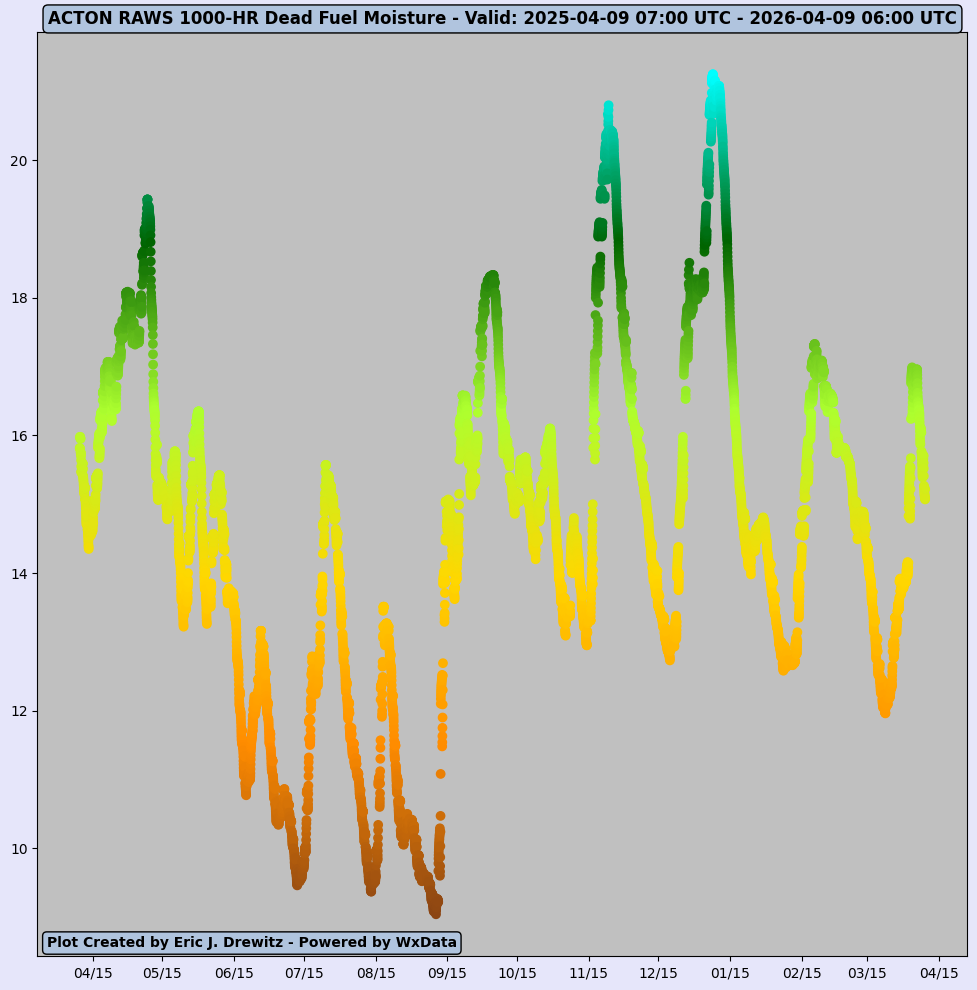

In [5]:
# Create our figure
fig = plt.figure(figsize=(12,12))

# Set facecolor of plot
fig.set_facecolor('lavender')

# Create our subplot axis
ax = fig.add_subplot(1,1,1)

# Set the background of the plot to grey
ax.set_facecolor('silver')

# Format the x-axis so it reflects datetime
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_major_formatter(md.DateFormatter('%m/%d'))
ax.xaxis.set_major_locator(md.DayLocator(15))

# Create a custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list("1000hr dead fuel moisture", ["saddlebrown", "darkorange", "gold", "greenyellow", "darkgreen", "cyan"])

ax.scatter(pd.to_datetime(df['observationTime']), df['thousandHR_TL_FuelMoisture'], c=df['thousandHR_TL_FuelMoisture'], cmap=cmap)

# Create a textbox
box = dict(boxstyle='round', facecolor='lightsteelblue')

# Create our title for our plot
ax.set_title(f"{df['stationName'].iloc[0]} RAWS 1000-HR Dead Fuel Moisture - Valid: {pd.to_datetime(df['observationTime'].iloc[0]).strftime('%Y-%m-%d %H:00 UTC')} - {pd.to_datetime(df['observationTime'].iloc[-1]).strftime('%Y-%m-%d %H:00 UTC')}", fontweight='bold', bbox=box)

# Create a signature
ax.text(0.01, 0.01, f"Plot Created by Eric J. Drewitz - Powered by WxData", transform=ax.transAxes, fontweight='bold', bbox=box)